### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [1]:
# [PATCHED] !pip install gymnasium

In [2]:
 # رفع الدرايف
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

In [3]:
# مسار مجلد العمل
working_folder='./'
# مسار النموذج
model_path = working_folder + "cartpole_dqn_model.h5"


In [4]:
# تحميل نموذج شبكة
from tensorflow.keras.models import load_model

# تحميل ملف النموذج
model = load_model(model_path)

# طباعة ملخص النموذج
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

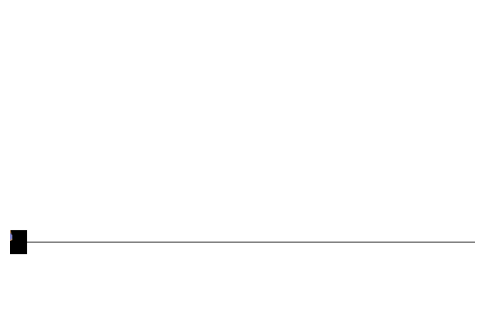

Total reward from the test episode: 89.0


In [5]:
# مكتبة البيئات
import gymnasium as gym
import numpy as np

# مكتبة الرسم
import matplotlib.pyplot as plt
# مكتبة العرض
from IPython.display import display, clear_output

# إنشاء البيئة
env = gym.make('CartPole-v1', render_mode='rgb_array')

# تهيئة البيئة
state, info = env.reset()

# إنشاء رسم بياني لعرض بيئة اللعبة
fig, ax = plt.subplots(figsize=(6, 6))

# تهيئة المتغيرات لاختبار النموذج
done = False
total_reward = 0

# حلقة لاختبار النموذج وعرض أداء الوكيل
while not done:
    # إعداد الحالة المناسبة لدخل الشبكة
    state = state.reshape(1, 4)

    # الحصول على قيم جودة الأفعال الموافقة للحالة
    q_values = model.predict(state, verbose=0)

    # إيجاد الفعل الموافق لأكبر قيمة
    action = np.argmax(q_values[0])

    # تنفيذ الفعل في البيئة
    next_state, reward, terminated, truncated, info = env.step(action)

    # الحصول على الإطار من البيئة
    frame = env.render()

    # تحديث الرسم البياني بالإطار الحالي من البيئة
    ax.clear()  # مسح الإطار السابق
    ax.imshow(frame)  # عرض الإطار الحالي
    ax.axis('off')  # إخفاء المحاور لتحسين العرض

    # مسح الإخراج السابق وعرض الشكل الحالي
    clear_output(wait=True)
    display(fig)
    plt.pause(1)  # التوقف مؤقتًا لإنشاء تأثير  الحركة

    # تحديث المكافأة الإجمالية والحالة
    total_reward += reward
    state = next_state  # الانتقال إلى الحالة التالية

    # التحقق من انتهاء الحلقة
    if terminated or truncated:
        done = True

# طباعة المكافأة الإجمالية التي تم الحصول عليها من الحلقة الاختبارية
print(f"Total reward from the test episode: {total_reward}")